# IMPORT LIBRARIES

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

In [2]:
from google.colab import drive

#
drive.mount('/content/drive')

Mounted at /content/drive


##CAMELS-DATA from my Google Drive.

In [3]:
# ==============================
# Paths to ZIP files
# ==============================
hydro_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/05_hydrometeorology.zip"
streamflow_zip = "/content/drive/MyDrive/Colab Notebooks/Dimension/03_streamflow.zip"

# Data extraction directories
hydro_dir = "/content/05_hydro"
streamflow_dir = "/content/03_streamflow"

# ==============================
# Function to extract ZIP files
# ==============================
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print(f"✅ ZIP extracted in {extract_to}")
    else:
        print(f"✅ Directory {extract_to} already exists")

def find_csv(base_dir, csv_name):
    # Recursive search for the CSV file
    for root, dirs, files in os.walk(base_dir):
        if csv_name in files:
            return os.path.join(root, csv_name)
    raise FileNotFoundError(f"{csv_name} not found in {base_dir}")

# ==============================
# Extraction
# ==============================
extract_zip(hydro_zip, hydro_dir)
extract_zip(streamflow_zip, streamflow_dir)

# ==============================
# Load the 222 basins data
# ==============================
file_path = '/content/drive/MyDrive/Colab Notebooks/Dimension/id_name_metadata.csv'
basin222 = pd.read_csv(file_path)
station_ids_v1 = basin222['station_id'].astype(str).str.strip().unique()
print(f"✅ {len(station_ids_v1)} official basins loaded")

# ==============================
# 1️⃣ Precipitation (SILO)
# ==============================
precip_file = find_csv(hydro_dir, "precipitation_SILO.csv")
precip = pd.read_csv(precip_file, index_col=0, parse_dates=True)
precip.columns = precip.columns.str.strip()
precip.replace(-99.99, np.nan, inplace=True)
print("✅ SILO precipitation:", precip.shape)

# ==============================
# 2️⃣ Evapotranspiration (ET SILO)
# ==============================
et_file = find_csv(hydro_dir, "et_morton_actual_SILO.csv")
et = pd.read_csv(et_file, index_col=0, parse_dates=True)
et.columns = et.columns.str.strip()
et.replace(-99.99, np.nan, inplace=True)
print("✅ SILO ET:", et.shape)

# ==============================
# 3️⃣ Streamflow
# ==============================
streamflow_file = find_csv(streamflow_dir, "streamflow_mmd.csv")
Q = pd.read_csv(streamflow_file, index_col=0, parse_dates=True)
Q.columns = Q.columns.str.strip()
Q.replace(-99.99, np.nan, inplace=True)
print("✅ Streamflow:", Q.shape)

# ==============================
# 4️⃣ Identify common stations
# ==============================
stations_precip = set(precip.columns)
stations_et = set(et.columns)
stations_Q = set(Q.columns)

common_stations = [
    s for s in station_ids_v1
    if s in stations_precip and s in stations_et and s in stations_Q
]

print(f"✅ Official common stations: {len(common_stations)}")

# ==============================
# 5️⃣ Subset common stations
# ==============================
precip = precip[common_stations]
et = et[common_stations]
Q = Q[common_stations]

# ==============================
# 6️⃣ Final verification
# ==============================
print("Precipitation:", precip.shape)
print("ET:", et.shape)
print("Streamflow:", Q.shape)
print("Stations (first 10):", common_stations[:10], "...")


✅ ZIP extracted in /content/05_hydro
✅ ZIP extracted in /content/03_streamflow
✅ 222 official basins loaded
✅ SILO precipitation: (43464, 224)
✅ SILO ET: (43464, 224)
✅ Streamflow: (23376, 224)
✅ Official common stations: 222
Precipitation: (43464, 222)
ET: (43464, 222)
Streamflow: (23376, 222)
Stations (first 10): ['912101A', '912105A', '915011A', '917107A', '919003A', '919201A', '919309A', '922101B', '925001A', '926002A'] ...


In [4]:
# Verification of the periods
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())


Precipitation : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
ET            : 1900-01-01 00:00:00 → 2018-01-01 00:00:00
Streamflow    : 1951-01-01 00:00:00 → 2014-01-01 00:00:00


In [5]:
# ==============================
# 0️⃣ Reduce all series to the period 1 January 1980 → 31 December 2014
# ==============================
start_date = "1980-01-01"
end_date   = "2014-12-31"

precip = precip.loc[start_date:end_date]
et     = et.loc[start_date:end_date]
Q      = Q.loc[start_date:end_date]

# Verification
print("Common period verification:")
print("Precipitation :", precip.index.min(), "→", precip.index.max())
print("ET            :", et.index.min(), "→", et.index.max())
print("Streamflow    :", Q.index.min(), "→", Q.index.max())

Common period verification:
Precipitation : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
ET            : 1980-01-01 00:00:00 → 2014-01-01 00:00:00
Streamflow    : 1980-01-01 00:00:00 → 2014-01-01 00:00:00


GRHyMoLAP

In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from numba import njit

# ============================================
# General parameters
# ============================================
start_date = "1980-01-01"
end_date = "2014-12-31"
b1_ratio = 0.7
max_missing_ratio = 1

stations = common_stations
results_GRHyMoLAP = {}

# ============================================
# Metrics definitions
# ============================================
@njit
def NSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.var(obs) == 0:
        return np.nan
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2)

@njit
def NNSE(nse):
    if np.isnan(nse):
        return np.nan
    return 1.0 / (2.0 - nse)

@njit
def RMSE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    return np.sqrt(np.mean((sim - obs)**2))

@njit
def PBIAS(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0 or np.sum(obs) == 0:
        return np.nan
    return  np.sum(sim - obs) / np.sum(obs)

@njit
def FHV(obs, sim, top_fraction=0.02):
    epsilon = 0
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_top = int(len(obs) * top_fraction)
    if n_top == 0:
        return np.nan
    idx = np.argsort(obs)[-n_top:]
    obs_top = obs[idx]
    sim_top = sim[idx]
    return  np.sum(sim_top - obs_top) / (np.sum(obs_top) + epsilon)

@njit
def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)

# ============================================
# Percolation function
# ============================================
@njit
def Percolation(Pn, En, X1):
    n = len(Pn)
    S = np.zeros(n)
    S[0] = X1 / 2
    Perc = np.zeros(n)
    ratio = (4.0 / 9.0) * (S[0] / X1)
    Perc[0] = S[0] * (1 - (1 + ratio**4) ** (-0.25))
    for i in range(1, n):
        temp = (S[i-1] / X1) ** 2
        frac = Pn[i] / X1
        Ps = X1 * (1 - temp) * np.tanh(frac) / (1 + (S[i-1] / X1) * np.tanh(frac))
        frac = En[i] / X1
        Es = S[i-1] * (2 - S[i-1]/X1) * np.tanh(frac) / (1 + (1 - S[i-1]/X1) * np.tanh(frac))
        S[i] = S[i-1] + Ps - Es
        ratio = (4.0 / 9.0) * (S[i] / X1)
        Perc[i] = S[i] * (1 - (1 + ratio**4) ** (-0.25))
        S[i] -= Perc[i]
    return Perc

# ============================================
# GRHyMoLAP simulation
# ============================================
@njit
def GRHyMoLAP_Model(params, Q0, Pn, En):
    MU, LAMBDA, X1, GAMMA = params
    N = len(Pn)
    Q = np.zeros(N)
    Q[0] = Q0
    Perc = Percolation(Pn, En, X1)
    for t in range(N-1):
        Q[t+1] = max(0, Q[t] - (MU / LAMBDA) * Q[t]**(2*MU - 1) + GAMMA * Perc[t+1] * Pn[t+1])
    return Q

# ============================================
# Main loop over basins with Nelder + L-BFGS-B fallback
# ============================================
for i, station_id in enumerate(stations, start=1):
    print(f"\n=== Station {station_id} ({i}/{len(stations)}) ===")

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET = et[station_id].loc[start_date:end_date].to_numpy(float)

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)
    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    missing_ratio = np.sum(np.isnan(Q_obs)) / N
    if missing_ratio > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    # Objective function
    def objective(params, Q0, Pn_train, En_train, Q_obs_train):
        Q_sim = GRHyMoLAP_Model(params, Q0, Pn_train, En_train)
        nse = NSE(Q_obs_train, Q_sim)
        return 1 - nse if np.isfinite(nse) else 1e9

    # Multi-start Nelder-Mead
    initial_guesses = [
        [1.0, 8, 150, 0.1],
        [0.6, 2, 120, 1],
        [1.4, 15, 200, 0.5]
    ]

    best_val = float("inf")
    best_res = None

    for guess in initial_guesses:
        res = minimize(
            objective, guess,
            args=(Q0, Pn[:b1], En[:b1], Q_obs[:b1]),
            method="Nelder-Mead",
            #bounds=bounds,
            options={'maxiter': 2500, 'disp': False}
        )
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    MU, LAMBDA, X1, GAMMA = best_res.x

    # Simulate
    Qsim = GRHyMoLAP_Model([MU, LAMBDA, X1, GAMMA], Q0, Pn, En)

    # Metrics
    NSE_cal = 1 - best_res.fun
    NNSE_cal = NNSE(NSE_cal)
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])
    NNSE_val = NNSE(NSE_val)

    rmse_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    pbias_cal = PBIAS(Q_obs[:b1], Qsim[:b1])
    fhv_cal = FHV(Q_obs[:b1], Qsim[:b1])
    flv_cal = FLV(Q_obs[:b1], Qsim[:b1])

    rmse_val = RMSE(Q_obs[b1:], Qsim[b1:])
    pbias_val = PBIAS(Q_obs[b1:], Qsim[b1:])
    fhv_val = FHV(Q_obs[b1:], Qsim[b1:])
    flv_val = FLV(Q_obs[b1:], Qsim[b1:])

    # Display
    print(f"✅ Calibration NSE: {NSE_cal:.3f}, Validation NSE: {NSE_val:.3f}")
    print(f"   Params: MU={MU:.3f}, LAMBDA={LAMBDA:.3f}, X1={X1:.3f}, GAMMA={GAMMA:.3f}")

    # Store results
    results_GRHyMoLAP[station_id] = {
        "params": [MU, LAMBDA, X1, GAMMA],
        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "NNSE_cal": NNSE_cal,
        "NNSE_val": NNSE_val,
        "RMSE_cal": rmse_cal,
        "PBIAS_cal": pbias_cal,
        "FHV_cal": fhv_cal,
        "FLV_cal": flv_cal,
        "RMSE_val": rmse_val,
        "PBIAS_val": pbias_val,
        "FHV_val": fhv_val,
        "FLV_val": flv_val,
        "Qsim": Qsim,
        "missing_ratio": missing_ratio
    }

print(f"\n✅ Simulation completed for {len(results_GRHyMoLAP)} basins.")


=== Station 912101A (1/222) ===
✅ Calibration NSE: 0.529, Validation NSE: 0.574
   Params: MU=0.859, LAMBDA=2.665, X1=112.080, GAMMA=0.112

=== Station 912105A (2/222) ===
✅ Calibration NSE: 0.649, Validation NSE: 0.654
   Params: MU=1.045, LAMBDA=5.433, X1=148.227, GAMMA=0.117

=== Station 915011A (3/222) ===
✅ Calibration NSE: 0.540, Validation NSE: 0.710
   Params: MU=1.027, LAMBDA=2.445, X1=195.836, GAMMA=0.139

=== Station 917107A (4/222) ===
✅ Calibration NSE: 0.803, Validation NSE: 0.678
   Params: MU=1.121, LAMBDA=4.232, X1=203.481, GAMMA=0.120

=== Station 919003A (5/222) ===
✅ Calibration NSE: 0.621, Validation NSE: 0.722
   Params: MU=1.036, LAMBDA=7.022, X1=128.921, GAMMA=0.147

=== Station 919201A (6/222) ===
✅ Calibration NSE: 0.431, Validation NSE: 0.468
   Params: MU=1.184, LAMBDA=10.740, X1=115.266, GAMMA=0.156

=== Station 919309A (7/222) ===
✅ Calibration NSE: 0.767, Validation NSE: 0.831
   Params: MU=1.087, LAMBDA=8.281, X1=183.824, GAMMA=0.133

=== Station 922101

## Sobol

In [8]:
!pip install SALib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 9.9 MB/s eta 0:00:00


In [9]:
# ======================================================
# SOBOL SENSITIVITY ANALYSIS (Separate from main code)
# ======================================================

from SALib.sample import saltelli
from SALib.analyze import sobol
import numpy as np

In [10]:
# -----------------------------
# 0️⃣ Imports
# -----------------------------
import numpy as np
from SALib.sample import saltelli
from SALib.analyze import sobol


# -----------------------------
# 1️⃣ Sobol problem definition
# -----------------------------
sobol_problem = {
    'num_vars': 4,
    'names': ['MU', 'LAMBDA', 'X1', 'GAMMA'],
    'bounds': [
        [0.25, 2.0],
        [0.001, 80.0],
        [0.001, 3500.0],
        [0.001, 18]
    ]
}

# -----------------------------
# 2️⃣ Number of Sobol samples
# -----------------------------
N_sobol = 1024 # power of 2 recommended

# -----------------------------
# 3️⃣ Prepare to store results
# -----------------------------
sobol_results = {}

# -----------------------------
# 4️⃣ Loop over basins
# -----------------------------
for i, station_id in enumerate(list(results_GRHyMoLAP.keys())[:], start=1):
    print(f"\n=== Basin {station_id} ({i}) ===")

    Q_obs = Q[station_id].loc[start_date:end_date].to_numpy(float)
    P     = precip[station_id].loc[start_date:end_date].to_numpy(float)
    PET   = et[station_id].loc[start_date:end_date].to_numpy(float)

    Q0 = Q_obs[0]
    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    # -----------------------------
    # 5️⃣ Generate Sobol samples
    # -----------------------------
    param_samples = saltelli.sample(sobol_problem, N_sobol, calc_second_order=True)

    # -----------------------------
    # 6️⃣ NSE wrapper with epsilon
    # -----------------------------
    eps = 1e-6
    def model_nse(params):
        Qsim = GRHyMoLAP_Model(params, Q0, Pn, En)
        mask = ~np.isnan(Q_obs) & ~np.isnan(Qsim)
        if np.sum(mask) == 0 or np.var(Q_obs[mask]) < eps:
            return 0.0
        return NSE(Q_obs[mask], Qsim[mask])

    # -----------------------------
    # 7️⃣ Evaluate all Sobol samples
    # -----------------------------
    Y = np.array([model_nse(p) for p in param_samples])

    # -----------------------------
    # 8️⃣ Sobol analysis
    # -----------------------------
    Si = sobol.analyze(sobol_problem, Y, calc_second_order=True, print_to_console=True)

    # -----------------------------
    # 9️⃣ Store results
    # -----------------------------
    sobol_results[station_id] = {
        'S1': Si['S1'],
        'ST': Si['ST'],
        'S2': Si['S2'],
        'S1_conf': Si['S1_conf'],
        'ST_conf': Si['ST_conf'],
        'S2_conf': Si['S2_conf']
    }

    print(f"First-order (S1) indices: {Si['S1']}")
    print(f"Total-order (ST) indices: {Si['ST']}")

print("\n✅ Sobol analysis completed.")


=== Basin 912101A (1) ===


/tmp/ipykernel_2220/2656012501.py:50: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_samples = saltelli.sample(sobol_problem, N_sobol, calc_second_order=True)


              ST   ST_conf
MU      0.806818  0.131014
LAMBDA  0.112949  0.056287
X1      0.044413  0.019290
GAMMA   0.503741  0.086928
              S1   S1_conf
MU      0.400230  0.093574
LAMBDA  0.017805  0.019060
X1     -0.000745  0.014236
GAMMA   0.153415  0.060168
                       S2   S2_conf
(MU, LAMBDA)     0.048054  0.145819
(MU, X1)         0.024009  0.141957
(MU, GAMMA)      0.287761  0.193266
(LAMBDA, X1)     0.024115  0.039962
(LAMBDA, GAMMA)  0.035788  0.050191
(X1, GAMMA)      0.017625  0.045538
First-order (S1) indices: [ 0.4002299   0.01780544 -0.00074451  0.15341514]
Total-order (ST) indices: [0.80681812 0.11294923 0.04441323 0.50374054]

=== Basin 912105A (2) ===


/tmp/ipykernel_2220/2656012501.py:50: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_samples = saltelli.sample(sobol_problem, N_sobol, calc_second_order=True)


              ST   ST_conf
MU      0.806635  0.130478
LAMBDA  0.111805  0.055648
X1      0.046371  0.018606
GAMMA   0.510697  0.108711
              S1   S1_conf
MU      0.421352  0.107215
LAMBDA -0.006569  0.036815
X1      0.001748  0.013439
GAMMA   0.151852  0.078043
                       S2   S2_conf
(MU, LAMBDA)     0.032182  0.148993
(MU, X1)        -0.011021  0.158388
(MU, GAMMA)      0.293036  0.249582
(LAMBDA, X1)     0.036575  0.045806
(LAMBDA, GAMMA)  0.058869  0.067831
(X1, GAMMA)      0.015748  0.046931
First-order (S1) indices: [ 0.42135212 -0.00656875  0.0017478   0.15185248]
Total-order (ST) indices: [0.80663457 0.11180499 0.04637061 0.51069736]

=== Basin 915011A (3) ===


...

              ST   ST_conf
MU      0.835086  0.149699
LAMBDA  0.184613  0.067537
X1      0.104901  0.053950
GAMMA   0.511990  0.101214
              S1   S1_conf
MU      0.370174  0.112487
LAMBDA  0.013953  0.027602
X1      0.008554  0.020193
GAMMA   0.181878  0.077450
                       S2   S2_conf
(MU, LAMBDA)     0.044434  0.134085
(MU, X1)        -0.009882  0.137219
(MU, GAMMA)      0.191803  0.191620
(LAMBDA, X1)     0.019443  0.045288
(LAMBDA, GAMMA)  0.030744  0.045454
(X1, GAMMA)      0.016376  0.055053
First-order (S1) indices: [0.37017356 0.01395255 0.00855366 0.18187799]
Total-order (ST) indices: [0.83508583 0.18461303 0.10490119 0.5119898 ]

=== Basin 315450 (221) ===


/tmp/ipykernel_2220/2656012501.py:50: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_samples = saltelli.sample(sobol_problem, N_sobol, calc_second_order=True)


              ST   ST_conf
MU      0.785143  0.125319
LAMBDA  0.026088  0.020733
X1      0.156891  0.054165
GAMMA   0.541324  0.093944
              S1   S1_conf
MU      0.399415  0.105273
LAMBDA -0.000273  0.005564
X1      0.017662  0.024918
GAMMA   0.201356  0.080268
                       S2   S2_conf
(MU, LAMBDA)    -0.034512  0.131514
(MU, X1)        -0.001904  0.131183
(MU, GAMMA)      0.213664  0.186085
(LAMBDA, X1)     0.000696  0.006809
(LAMBDA, GAMMA) -0.001447  0.013393
(X1, GAMMA)      0.051207  0.077706
First-order (S1) indices: [ 3.99415094e-01 -2.73313672e-04  1.76617285e-02  2.01355883e-01]
Total-order (ST) indices: [0.7851431  0.02608765 0.15689137 0.54132393]

=== Basin 318076 (222) ===


/tmp/ipykernel_2220/2656012501.py:50: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_samples = saltelli.sample(sobol_problem, N_sobol, calc_second_order=True)


              ST   ST_conf
MU      0.803338  0.132595
LAMBDA  0.055181  0.032898
X1      0.079461  0.038107
GAMMA   0.540639  0.090290
              S1   S1_conf
MU      0.429705  0.096741
LAMBDA  0.006645  0.014341
X1      0.005425  0.018479
GAMMA   0.188979  0.075767
                       S2   S2_conf
(MU, LAMBDA)    -0.023448  0.117516
(MU, X1)        -0.026219  0.121071
(MU, GAMMA)      0.254937  0.170098
(LAMBDA, X1)    -0.007105  0.014388
(LAMBDA, GAMMA) -0.007341  0.020877
(X1, GAMMA)      0.036022  0.071502
First-order (S1) indices: [0.42970542 0.00664505 0.00542491 0.1889786 ]
Total-order (ST) indices: [0.80333847 0.0551815  0.07946092 0.54063934]

✅ Sobol analysis completed.



=== Summary Table ===
  Parameter  S1_mean  S1_std  ST_mean  ST_std
0     $X_1$    0.010   0.011    0.121   0.067
1         γ    0.140   0.048    0.508   0.035
2         λ   -0.001   0.007    0.062   0.053
3         μ    0.433   0.054    0.884   0.094


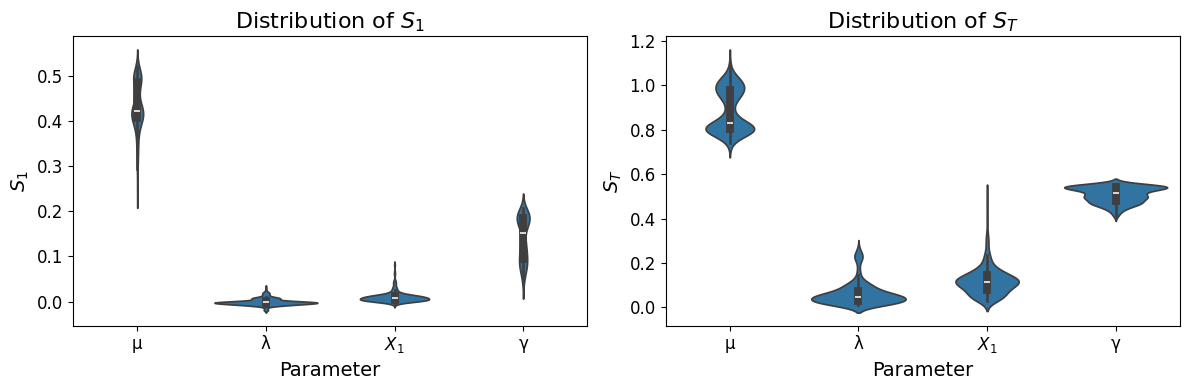

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1️⃣ Convert sobol_results → DataFrame long
# ==========================================

# Parameters
param_names = ['μ', 'λ', r"$X_1$", 'γ']

rows = []

for basin, res in sobol_results.items():
    for i, p in enumerate(param_names):
        rows.append({
            "Basin": basin,
            "Parameter": p,
            "S1": res["S1"][i],
            "ST": res["ST"][i]
        })

df = pd.DataFrame(rows)

# ==========================================
# 2️⃣ Summary statistics
# ==========================================

summary = df.groupby("Parameter").agg({
    "S1": ["mean", "std"],
    "ST": ["mean", "std"]
}).round(3)

summary.columns = ['S1_mean', 'S1_std', 'ST_mean', 'ST_std']
summary = summary.reset_index()

print("\n=== Summary Table ===")
print(summary)

# ==========================================
# 3️⃣ Export (CSV + LaTeX)
# ==========================================

summary.to_csv("sobol_summary.csv", index=False)

# Parameters for table
df_latex = summary.copy()
df_latex["Parameter"] = df_latex["Parameter"].apply(lambda x: f"${x}$")
latex_table = df_latex.to_latex(index=False, float_format="%.3f", escape=False)
with open("sobol_summary.tex", "w") as f:
    f.write(latex_table)


# ==========================================
# 5️⃣ VIOLIN PLOTS (OPTION)
# ==========================================

plt.figure(figsize=(12,4))

#
title_fontsize = 16
label_fontsize = 14
tick_fontsize = 12

plt.subplot(1,2,1)
sns.violinplot(data=df, x="Parameter", y="S1")
plt.title("Distribution of $S_1$", fontsize=title_fontsize)
plt.xlabel("Parameter", fontsize=label_fontsize)
plt.ylabel("$S_1$", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.subplot(1,2,2)
sns.violinplot(data=df, x="Parameter", y="ST")
plt.title("Distribution of $S_T$", fontsize=title_fontsize)
plt.xlabel("Parameter", fontsize=label_fontsize)
plt.ylabel("$S_T$", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.tight_layout()
plt.savefig("sobol_violin.jpeg", dpi=700)
#files.download("sobol_violin.jpeg")  # si tu veux télécharger
plt.show()